Cloning into 'atri_assignment'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 11 (delta 0), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 5.33 KiB | 2.66 MiB/s, done.
/content/atri_assignment


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


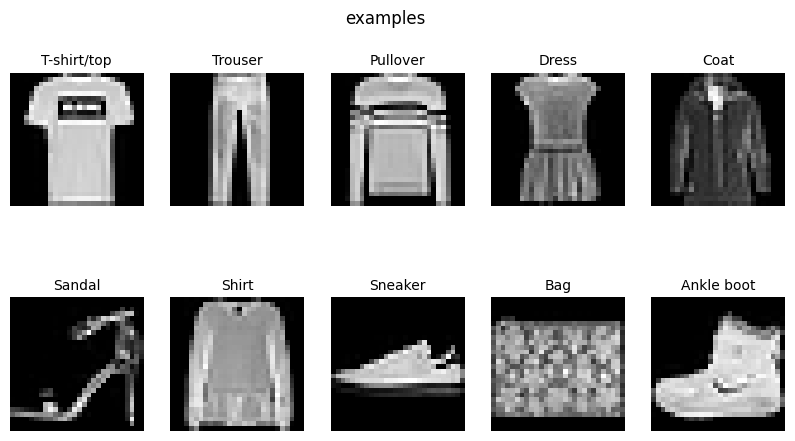

In [ ]:
!git clone https://github.com/Mowriyan-2/atri_assignment
%cd atri_assignment
!pip install wandb keras -q
import sys
sys.path.insert(0, '.')

from src.data import load_fashion_mnist, plot_class_examples
import wandb

wandb.login()
run = wandb.init(project="atri-fashion-mnist", name="q1_sample_images")

(X_train, y_train), (X_test, y_test) = load_fashion_mnist()

fig = plot_class_examples(X_train, y_train)   # this both returns AND shows the matplotlib figure inline in Colab
wandb.log({"examples": wandb.Image(fig)})      # this pushes it to your wandb dashboard

run.finish()

In [ ]:
# Cell 1: Setup
!git clone https://github.com/Mowriyan-2/atri_assignment.git
%cd atri_assignment
!pip install wandb keras -q

import sys
sys.path.insert(0, '.')
import wandb
wandb.login()

Cloning into 'atri_assignment'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 11 (delta 0), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 5.33 KiB | 2.66 MiB/s, done.
/content/atri_assignment/atri_assignment


True

In [ ]:
# Cell 2: Load data
from src.data import load_fashion_mnist, preprocess, one_hot, train_val_split
import numpy as np

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = load_fashion_mnist()

X_train = preprocess(X_train_raw)
y_train_oh = one_hot(y_train_raw)
X_tr, y_tr, X_val, y_val = train_val_split(X_train, y_train_oh, val_fraction=0.1)

print(X_tr.shape, X_val.shape)

(54000, 784) (6000, 784)


In [ ]:
# Cell 3: Train with ONE optimizer and log to wandb
from src.nn import NeuralNetwork
from src.losses import LOSSES
from src.optimizers import OPTIMIZERS

run = wandb.init(project="atri-fashion-mnist", name="q3_adam_test",
                  config={"optimizer": "adam", "lr": 1e-3, "batch_size": 64,
                          "hidden_layers": [128, 64], "activation": "relu", "epochs": 10})
config = wandb.config

model = NeuralNetwork(input_size=784, hidden_layers=config.hidden_layers,
                       output_size=10, activation=config.activation, weight_init="xavier")
loss_fwd, loss_grad = LOSSES["cross_entropy"]
optimizer = OPTIMIZERS[config.optimizer](model.get_params(), model.is_weight_mask(), lr=config.lr)

for epoch in range(config.epochs):
    idx = np.random.permutation(len(X_tr))
    epoch_loss = 0
    n_batches = 0

    for start in range(0, len(X_tr), config.batch_size):
        b = idx[start:start + config.batch_size]
        probs, cache = model.forward(X_tr[b])
        grads = model.backward(cache, y_tr[b], loss_grad)
        optimizer.step(grads)
        epoch_loss += loss_fwd(probs, y_tr[b])
        n_batches += 1

    train_loss = epoch_loss / n_batches
    val_probs, _ = model.forward(X_val)
    val_loss = loss_fwd(val_probs, y_val)
    val_acc = np.mean(np.argmax(val_probs, axis=1) == np.argmax(y_val, axis=1))

    wandb.log({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_accuracy": val_acc})
    print(f"epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

run.finish()

epoch 0: train_loss=0.5316 val_loss=0.3871 val_acc=0.8647
epoch 1: train_loss=0.3815 val_loss=0.3587 val_acc=0.8725
epoch 2: train_loss=0.3444 val_loss=0.3508 val_acc=0.8722
epoch 3: train_loss=0.3183 val_loss=0.3195 val_acc=0.8838
epoch 4: train_loss=0.3032 val_loss=0.3060 val_acc=0.8892
epoch 5: train_loss=0.2854 val_loss=0.3032 val_acc=0.8907
epoch 6: train_loss=0.2728 val_loss=0.2960 val_acc=0.8922
epoch 7: train_loss=0.2604 val_loss=0.3055 val_acc=0.8873
epoch 8: train_loss=0.2526 val_loss=0.2940 val_acc=0.8950
epoch 9: train_loss=0.2453 val_loss=0.3062 val_acc=0.8922


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▃▂▂▂▁▁▁
val_accuracy,▁▃▃▅▇▇▇▆█▇
val_loss,█▆▅▃▂▂▁▂▁▂
epoch,9
train_loss,0.24535
val_accuracy,0.89217
val_loss,0.30617


In [ ]:
for opt_name in OPTIMIZERS:
    run = wandb.init(project="atri-fashion-mnist", name=f"q3_{opt_name}_compare",
                      config={"optimizer": opt_name, "lr": 1e-3, "batch_size": 64,
                              "hidden_layers": [128, 64], "activation": "relu", "epochs": 5},
                      reinit=True)
    config = wandb.config

    model = NeuralNetwork(input_size=784, hidden_layers=config.hidden_layers,
                           output_size=10, activation=config.activation, weight_init="xavier")
    optimizer = OPTIMIZERS[config.optimizer](model.get_params(), model.is_weight_mask(), lr=config.lr)

    for epoch in range(config.epochs):
        idx = np.random.permutation(len(X_tr))
        for start in range(0, len(X_tr), config.batch_size):
            b = idx[start:start + config.batch_size]

            if optimizer.needs_lookahead():
                real_params = model.snapshot_params()
                model.set_params(optimizer.lookahead_params())
                probs, cache = model.forward(X_tr[b])
                grads = model.backward(cache, y_tr[b], loss_grad)
                model.set_params(real_params)
                optimizer.step(grads)
            else:
                probs, cache = model.forward(X_tr[b])
                grads = model.backward(cache, y_tr[b], loss_grad)
                optimizer.step(grads)

        val_probs, _ = model.forward(X_val)
        val_loss = loss_fwd(val_probs, y_val)
        val_acc = np.mean(np.argmax(val_probs, axis=1) == np.argmax(y_val, axis=1))
        wandb.log({"epoch": epoch, "val_loss": val_loss, "val_accuracy": val_acc})

    run.finish()

epoch,▁▃▅▆█
val_accuracy,▁▅▆▇█
val_loss,█▄▃▂▁
epoch,4
val_accuracy,0.75417
val_loss,0.75424


epoch,▁▃▅▆█
val_accuracy,▁▆▆██
val_loss,█▄▃▂▁
epoch,4
val_accuracy,0.84183
val_loss,0.43864


epoch,▁▃▅▆█
val_accuracy,▁▅▇██
val_loss,█▄▂▂▁
epoch,4
val_accuracy,0.842
val_loss,0.44571


epoch,▁▃▅▆█
val_accuracy,▃▁█▇█
val_loss,▇█▁▁▁
epoch,4
val_accuracy,0.87983
val_loss,0.33429


epoch,▁▃▅▆█
val_accuracy,▁▅▆██
val_loss,█▄▃▁▁
epoch,4
val_accuracy,0.88567
val_loss,0.30925


epoch,▁▃▅▆█
val_accuracy,▁▃▅██
val_loss,█▆▃▁▁
epoch,4
val_accuracy,0.883
val_loss,0.31585


In [ ]:
!git clone  https://github.com/Mowriyan-2/atri_assignment
%cd atri_assignment
!pip install wandb keras -q

import wandb
wandb.login()

Cloning into 'atri_assignment'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 36 (delta 8), reused 21 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 44.62 KiB | 7.44 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/atri_assignment/atri_assignment


True

In [ ]:
!git pull
!wandb sweep sweep.yaml

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 280 bytes | 280.00 KiB/s, done.
From https://github.com/Mowriyan-2/atri_assignment
   bd31cce..ca7c398  main       -> origin/main
Updating bd31cce..ca7c398
Fast-forward
 sweep.yaml | 1 +
 1 file changed, 1 insertion(+)
wandb: Creating sweep from: sweep.yaml
wandb: Creating sweep with ID: qn5zpuvu
wandb: View sweep at: https://wandb.ai/mowriyan52-iit-kharagpur/atri-fashion-mnist/sweeps/qn5zpuvu
wandb: Run sweep agent with: wandb agent mowriyan52-iit-kharagpur/atri-fashion-mnist/qn5zpuvu


In [ ]:
!wandb agent --count 80 mowriyan52-iit-kharagpur/atri-fashion-mnist/qn5zpuvu

Streaming output truncated to the last 5000 lines.
wandb: ⡿ setting up run 97wnhmal (3.0s)
wandb: ⢿ setting up run 97wnhmal (3.0s)
wandb: ⣻ setting up run 97wnhmal (3.0s)
wandb: ⣽ setting up run 97wnhmal (3.5s)
wandb: ⣾ setting up run 97wnhmal (3.5s)
wandb: ⣷ setting up run 97wnhmal (3.5s)
wandb: ⣯ setting up run 97wnhmal (3.5s)
wandb: ⣟ setting up run 97wnhmal (3.5s)
wandb: ⡿ setting up run 97wnhmal (4.0s)
wandb: ⢿ setting up run 97wnhmal (4.0s)
wandb: ⣻ setting up run 97wnhmal (4.0s)
wandb: ⣽ setting up run 97wnhmal (4.0s)
wandb: ⣾ setting up run 97wnhmal (4.0s)
wandb: ⣷ setting up run 97wnhmal (4.5s)
wandb: ⣯ setting up run 97wnhmal (4.5s)
wandb: ⣟ setting up run 97wnhmal (4.5s)
wandb: ⡿ setting up run 97wnhmal (4.5s)
wandb: ⢿ setting up run 97wnhmal (4.5s)
wandb: ⣻ setting up run 97wnhmal (5.0s)
wandb: ⣽ setting up run 97wnhmal (5.0s)
wandb: ⣾ setting up run 97wnhmal (5.0s)
wandb: ⣷ setting up run 97wnhmal (5.0s)
wandb: ⣯ setting up run 97wnhmal (5.0s)
wandb: Tracking run with wand

In [ ]:
!git clone  https://github.com/Mowriyan-2/atri_assignment
%cd atri_assignment

Cloning into 'atri_assignment'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 46 (delta 13), reused 29 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 47.33 KiB | 6.76 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/atri_assignment


In [7]:
!git pull
!python best_model_eval.py

Already up to date.
2026-07-25 19:41:51.936036: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-25 19:41:52.009863: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: App

In [8]:
!python loss_comparison.py

2026-07-25 19:43:33.613099: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-25 19:43:33.693343: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: mowriyan52 (mowriyan52-iit-kharagpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: ⢿ setting up run hzm7kqgd (0.0s)
wandb: ⣻ setting up run hzm7kqgd (0.0s)
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /content/atri_assignment/wandb/run-2

In [4]:
!git clone  https://github.com/Mowriyan-2/atri_assignment
%cd atri_assignment

fatal: destination path 'atri_assignment' already exists and is not an empty directory.
/content/atri_assignment


In [5]:
!git pull
!python mnist_experiments.py

Already up to date.
2026-07-26 14:54:49.301951: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-26 14:54:49.344764: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
w